In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

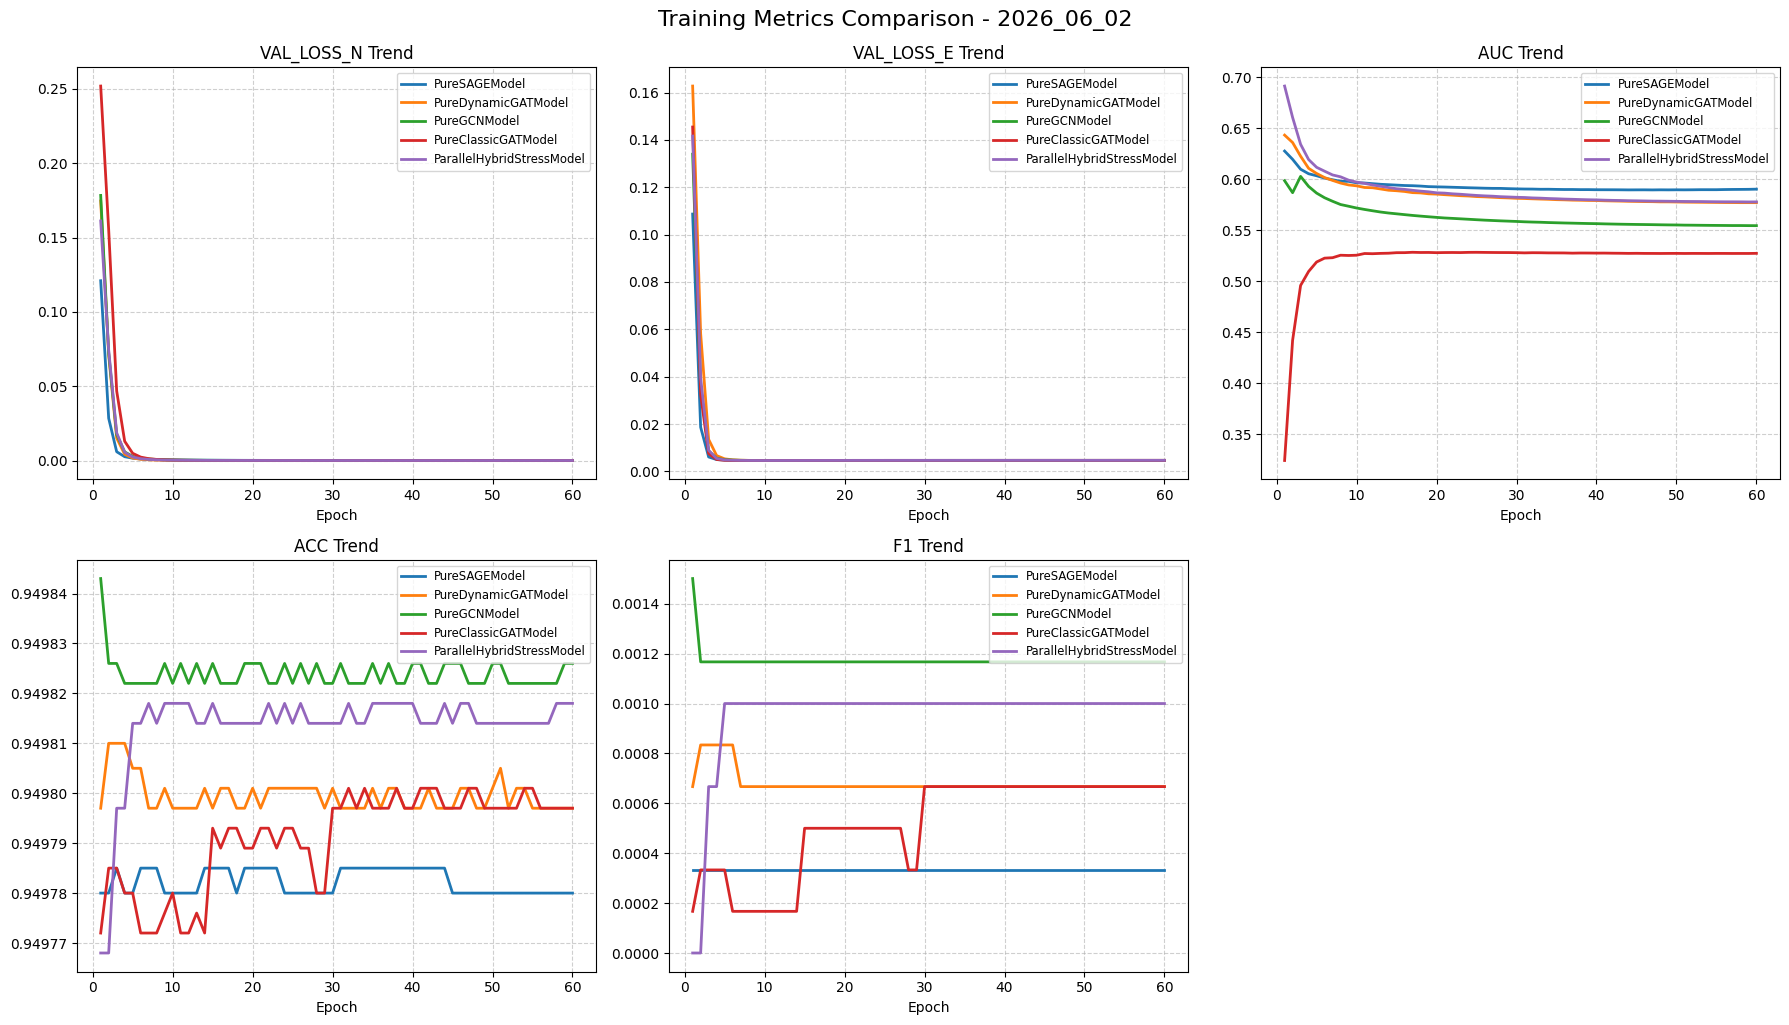

In [7]:
def plot_stress_metrics(save_root, date_str, model_names):
    """
    可视化 6 个核心指标：Loss_N, Loss_E, AUC, ACC, F1
    """
    # 更新后的指标列名
    metrics = ['val_loss_n', 'val_loss_e', 'auc', 'acc', 'f1']
    #metrics = ['val_loss', 'auc', 'acc', 'f1']
    # 设置 2行3列 的画布，尺寸更大
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # 调色板，确保多模型对比时颜色区分明显
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, model_name in enumerate(model_names):
        csv_path = os.path.join(save_root, date_str, model_name, 'val_metrics.csv')
        
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            
            for i, metric in enumerate(metrics):
                axes[i].plot(df['epoch'], df[metric], label=model_name, color=colors[idx % len(colors)], linewidth=2)
                axes[i].set_title(f'{metric.upper()} Trend')
                axes[i].set_xlabel('Epoch')
                axes[i].grid(True, linestyle='--', alpha=0.6)
                axes[i].legend(fontsize='small')
        else:
            print(f"⚠️ 警告：未找到模型 {model_name} 的数据，路径: {csv_path}")
            
    # 隐藏多余的第 6 个格子（因为我们只有 5 个指标）
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Training Metrics Comparison - {date_str}", fontsize=16, y=1.02)
    plt.show()

# --- 使用示例 ---
save_root = "./trained_model" # 修改为你的根目录
date_str = "2026_06_02" # 自动获取今天日期
model_names = ["PureSAGEModel", "PureDynamicGATModel", "PureGCNModel", "PureClassicGATModel", "ParallelHybridStressModel"]

plot_stress_metrics(save_root, date_str, model_names)